In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

In [2]:
# Chamar df e filtrar para nossa liga inicial
df_raw = pd.read_csv('cleaned_data/df_odds.csv', parse_dates=['date'], low_memory=False)

df_raw = df_raw[df_raw['league'] == 22614].copy()

In [3]:
cols_to_save = [
    "event_id",
    "date",
    "away_team",
    "away_player",
    "away_score",
    "home_team",
    "home_player",
    "home_score",
    "total_score",
]

df_raw[cols_to_save].to_csv('data_22614.csv', index=False)

In [4]:
from striker_training import split_data, input_averages

In [5]:
# Pré-processamento de dados
train_raw, test_raw = split_data(
    df=df_raw,
    split_date=datetime(2025,8,1),
    date_column='date'
)

In [6]:
# Agora temos as médias de 50 partidas para os jogadores
train_with_avg, test_with_avg, scaler = input_averages(train_raw, test_raw, return_scaler=True)

In [11]:
# Filtrar o dataframe
features =[
    "ma_home", "ma_away",
    "ma_h2h",
    "std_home", "std_away",
    "std_h2h"]

X_train = train_with_avg[features]
y_train = train_with_avg['total_score']

X_test = test_with_avg[features]
y_test = test_with_avg['total_score']

In [12]:
### Começar a TSCV normal

In [13]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error

In [14]:
X = X_train.values
y = y_train.values

In [15]:
def timeseries_cv_rmse(X, y, params, n_splits=5):
    rmse_scores = []
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for train_index, val_index in tscv.split(X):
        X_tr, X_val = X[train_index], X[val_index]
        y_tr, y_val = y[train_index], y[val_index]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        train_params = {
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "subsample": params["subsample"],
            "colsample_bytree": params["colsample_bytree"],
            "min_child_weight": params["min_child_weight"],
            "gamma": params["gamma"],
            "reg_alpha": params["reg_alpha"],
            "reg_lambda": params["reg_lambda"],
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "seed": 42,
        }

        evals = [(dval, "eval"), (dtrain, "train")]

        bst = xgb.train(
            params=train_params,
            dtrain=dtrain,
            num_boost_round=params["n_estimators"],
            evals=evals,
            early_stopping_rounds=30,
            verbose_eval=False
        )

        y_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration+1))
        rmse = root_mean_squared_error(y_val, y_pred)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [16]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
    }

    return timeseries_cv_rmse(X, y, params, n_splits=5)

In [17]:
# Rodar o Optuna

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Melhores parâmetros encontrados:", study.best_params)
print("Melhor RMSE médio:", study.best_value)


[I 2025-09-17 09:59:04,251] A new study created in memory with name: no-name-742ebbdd-4c22-4556-96c6-1ad38a5779ce
[I 2025-09-17 09:59:05,638] Trial 0 finished with value: 2.2367340564727782 and parameters: {'n_estimators': 143, 'learning_rate': 0.11566498510669969, 'max_depth': 6, 'subsample': 0.766066663576239, 'colsample_bytree': 0.8984592858952304, 'min_child_weight': 1, 'gamma': 1.9827504846889643, 'reg_alpha': 0.888262636013407, 'reg_lambda': 5.625445166419885}. Best is trial 0 with value: 2.2367340564727782.
[I 2025-09-17 09:59:06,357] Trial 1 finished with value: 2.203691339492798 and parameters: {'n_estimators': 118, 'learning_rate': 0.013157652293674577, 'max_depth': 6, 'subsample': 0.6622152130120428, 'colsample_bytree': 0.85381318036464, 'min_child_weight': 3, 'gamma': 4.959727942328557, 'reg_alpha': 0.7630740019882861, 'reg_lambda': 1.3118689480403383}. Best is trial 1 with value: 2.203691339492798.
[I 2025-09-17 09:59:07,331] Trial 2 finished with value: 2.1917901992797852

Melhores parâmetros encontrados: {'n_estimators': 400, 'learning_rate': 0.029323460658030247, 'max_depth': 1, 'subsample': 0.646135085842701, 'colsample_bytree': 0.7141319796133814, 'min_child_weight': 8, 'gamma': 1.136223260846358, 'reg_alpha': 0.07801372716349575, 'reg_lambda': 8.645378221471441}
Melhor RMSE médio: 2.1917901992797852


In [18]:
# Treinar e avaliar no holdout
params = {'n_estimators': 400, 'learning_rate': 0.029323460658030247, 'max_depth': 1, 'subsample': 0.646135085842701, 'colsample_bytree': 0.7141319796133814, 'min_child_weight': 8, 'gamma': 1.136223260846358, 'reg_alpha': 0.07801372716349575, 'reg_lambda': 8.645378221471441}



# ==============================
final_model = xgb.XGBRegressor(**params)

final_model.fit(X, y)

X_holdout = X_test.values
y_holdout = y_test.values

y_pred_holdout = final_model.predict(X_holdout)
rmse_holdout = root_mean_squared_error(y_holdout, y_pred_holdout)

print(f"\nRMSE no Holdout: {rmse_holdout:.4f}")



RMSE no Holdout: 2.2072


In [19]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df)

    feature  importance
2    ma_h2h    0.561034
1   ma_away    0.187102
0   ma_home    0.185857
5   std_h2h    0.031917
3  std_home    0.017652
4  std_away    0.016439


In [20]:
from scipy.stats import poisson

test_with_avg['pred'] = y_pred_holdout
df = test_with_avg.copy()

In [21]:
def poisson_goals(
    lambda_pred: float,
    handicap: float
    ) -> tuple[float, float]:

    """
    Calculate the Probability of a given Goal Line (Handicap).
    TODO: Create Poisson Probabilities for other markets.
    """
    def half_goal_handicap(handicap, lambda_pred) -> tuple[float,float]:
        prob_over = 1 - (poisson.cdf(int(handicap), lambda_pred))
        prob_under = (poisson.cdf(int(handicap), lambda_pred))
        
        return float(prob_over), float(prob_under)
    
    def integer_handicap(handicap,lambda_pred) -> tuple[float,float]:
        prob_over_raw = 1 - (poisson.cdf(int(handicap), lambda_pred))
        prob_under_raw = (poisson.cdf(int(handicap) - 1, lambda_pred))
        
        total = prob_over_raw + prob_under_raw
        
        prob_over = prob_over_raw / total
        prob_under = prob_under_raw / total

        return float(prob_over), float(prob_under)
    
    def quarter_handicap(handicap,lambda_pred) -> tuple[float,float]:
        
        lower = handicap - 0.25
        upper = handicap + 0.25
        probs_over = []
        probs_under = []

        for line in lower, upper:
            if line % 1 == 0.5:
                over, under = half_goal_handicap(
                handicap=line,
                lambda_pred=lambda_pred
            )
                
            elif line % 1 == 0.0:  
                over, under = integer_handicap(
                handicap=line,
                lambda_pred=lambda_pred
            )
            
            probs_over.append(over)
            probs_under.append(under)
        
        prob_over = sum(probs_over) / len(probs_over) 
        prob_under = sum(probs_under) / len(probs_under)
        
        return float(prob_over), float(prob_under)

    if handicap % 1 == 0.5:
        prob_over, prob_under = half_goal_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )

    elif handicap % 1 == 0.0:  
        prob_over, prob_under = integer_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )

    elif handicap % 1 in [0.25, 0.75]:  
        prob_over, prob_under = quarter_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )
    
    else:
        print(f'Invalid Handicap used to estimate goal probabilities: {handicap}')
        raise ValueError(f"Handicap inválido: {handicap}")
    
    return prob_over, prob_under

def profit(bet_type: str, handicap: float, total_score: int, bet_odd: float) -> float:
    
    """
    Calcular o PL dado um tipo de aposta, handicap, odd e resultado.
    TODO: Permitir outros mercados.
    TODO: Permitir stake variável.
    """

    if bet_type.lower() == 'over': outcome = total_score - handicap
    elif bet_type.lower() == 'under': outcome = handicap - total_score

    try:
        if outcome >= 0.5: 
            profit = (bet_odd - 1)
        
        elif outcome == 0.25:
            profit = (bet_odd - 1) / 2

        elif outcome == 0: 
            profit = 0
        
        elif outcome == -0.25:
            profit = -0.5

        
        elif outcome <= -0.5: 
            profit = -1
        
        return profit
        
    except: 
        print(f"Ajuste de resultado inválido: {outcome}")
        return 0

def ev(odd, prob):
    return odd * prob -1

def goal_handicap(handicap) -> float | None:

    """
    Gets the handicap from the API and solves type errors,
    Also, converts it to a float and returns the current handicap if successful.
    """

    try: 
        if isinstance(handicap, str):
            if ',' in handicap:
                handicap_vals = [float(h.strip()) for h in handicap.split(',')]
                handicap = sum(handicap_vals) / len(handicap_vals)
            
            else:
                handicap = float(handicap.strip())
        
        return handicap
    
    except ValueError as ve:
        print(f"Error converting handicap '{handicap}': {ve}")


In [22]:
# Criar DF de Backtesting
df['1_3_handicap'] = df['1_3_handicap'].apply(goal_handicap)

# transformar valores inválidos em NaN e converter para float
cols = ['1_3_handicap', '1_3_over_od', '1_3_under_od', 'total_score', 'pred']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # inválidos → NaN

# extrair colunas como arrays NumPy
handicap = df['1_3_handicap'].values
over_od = df['1_3_over_od'].values
under_od = df['1_3_under_od'].values
total_score = df['total_score'].values
pred = df['pred'].values

# calcular probabilidades (somente onde não é NaN)
valid_mask = ~(
    np.isnan(handicap) |
    np.isnan(over_od) |
    np.isnan(under_od) |
    np.isnan(total_score) |
    np.isnan(pred)
)

probs = np.full((len(df), 2), np.nan)  # inicializa com NaN
probs[valid_mask] = np.array([
    poisson_goals(p, h) for p, h in zip(pred[valid_mask], handicap[valid_mask])
])
prob_over = probs[:, 0]
prob_under = probs[:, 1]

# expectativa de valor
ev_over = np.full(len(df), np.nan)
ev_over[valid_mask] = [ev(o, prob) for o, prob in zip(over_od[valid_mask], prob_over[valid_mask])]

ev_under = np.full(len(df), np.nan)
ev_under[valid_mask] = [ev(u, prob) for u, prob in zip(under_od[valid_mask], prob_under[valid_mask])]

# inicializar arrays de saída
ev_bet = np.full(len(df), np.nan)
bet_type = np.full(len(df), None, dtype=object)
bet_profit = np.full(len(df), np.nan)

# escolher entre over e under
mask_over = valid_mask & (ev_over > ev_under) & (ev_over > 0)
mask_under = valid_mask & (ev_under >= ev_over) & (ev_under > 0)

# quando over é melhor
ev_bet[mask_over] = ev_over[mask_over]
bet_type[mask_over] = "over"

bet_profit[mask_over] = [
    profit("over", h, ts, o)
    for h, ts, o in zip(handicap[mask_over], total_score[mask_over], over_od[mask_over])
]

# quando under é melhor
ev_bet[mask_under] = ev_under[mask_under]
bet_type[mask_under] = "under"
bet_profit[mask_under] = [
    profit("under", h, ts, o)
    for h, ts, o in zip(handicap[mask_under], total_score[mask_under], under_od[mask_under])
]

# salvar no dataframe
df['over_prob'] = prob_over
df['under_prob'] = prob_under
df['ev_over'] = ev_over
df['ev_under'] = ev_under
df['ev_bet'] = ev_bet
df['bet_type'] = bet_type
df['bet_profit'] = bet_profit

In [23]:
import matplotlib.pyplot as plt

In [24]:
def lucro_por_threshold(df, step=0.01, max_threshold=1.0):
    """
    Calcula métricas por threshold de EV:
      - Lucro total
      - ROI (lucro / número de apostas)

    Espera colunas:
        'ev_bet' : valor esperado
        'bet_profit' : lucro/prejuízo da aposta
    """
    thresholds = np.arange(0, max_threshold + step, step)
    results = []

    for t in thresholds:
        mask = df['ev_bet'] >= t
        df_filtrado = df.loc[mask]

        total_profit = df_filtrado['bet_profit'].sum(skipna=True)
        num_bets = df_filtrado.shape[0]

        roi = total_profit / num_bets if num_bets > 0 else np.nan

        results.append({
            "threshold": round(t, 2),
            "total_profit": total_profit,
            "roi": roi
        })

    return pd.DataFrame(results)

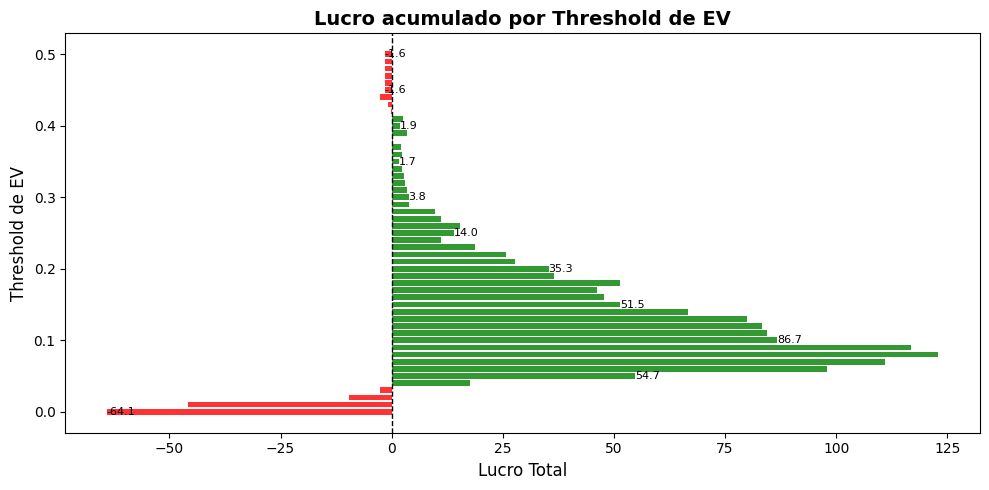

In [25]:
# Plotar saldo por EV Threshold
resultados = lucro_por_threshold(df, step=0.01, max_threshold=0.5)

plt.figure(figsize=(10,5))

# cores: verde se lucro > 0, vermelho se <= 0
colors = np.where(resultados['total_profit'] >= 0, 'green', 'red')

bars = plt.barh(
    resultados['threshold'],
    resultados['total_profit'],
    height=0.008,
    align='center',
    color=colors,
    alpha=0.8
)

# linha de referência vertical em x=0
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# títulos e labels
plt.ylabel("Threshold de EV", fontsize=12)
plt.xlabel("Lucro Total", fontsize=12)
plt.title("Lucro acumulado por Threshold de EV", fontsize=14, weight="bold")

# rótulos numéricos no fim das barras (a cada 5 thresholds)
for bar in bars[::5]:
    width = bar.get_width()
    if not np.isnan(width):
        plt.text(
            width,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}",
            ha='left', va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()


In [26]:
def desempenho_por_data(df, ev_ts: float) -> pd.DataFrame:
    """
    Calcula métricas diárias aplicando um threshold de EV.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com colunas:
          - 'date' (datetime)
          - 'ev_bet' (valor esperado da aposta)
          - 'bet_profit' (lucro/prejuízo da aposta)
    ev_ts : float
        Threshold de EV (filtra apenas apostas com ev_bet >= ev_ts)

    Returns
    -------
    pd.DataFrame
        Índice = datas
        Colunas:
          - 'total_profit' : lucro do dia
          - 'num_bets' : número de apostas do dia
          - 'roi' : lucro / nº de apostas
          - 'saldo_acumulado' : lucro acumulado ao longo dos dias
    """
    # filtrar pelas apostas acima do threshold
    df_filtrado = df.loc[df['ev_bet'] >= ev_ts].copy()

    # agrupar por data
    daily = (
        df_filtrado
        .groupby(df_filtrado['date'].dt.date)
        .agg(
            total_profit=("bet_profit", "sum"),
            num_bets=("bet_profit", "count")
        )
    )

    # calcular ROI e saldo acumulado
    daily["roi"] = daily["total_profit"] / daily["num_bets"]
    daily["saldo_acumulado"] = daily["total_profit"].cumsum()

    return daily.reset_index().rename(columns={"date": "data"})

In [27]:
desempenho_por_data(df, ev_ts=0.15)

,data,total_profit,num_bets,roi,saldo_acumulado
0,2025-08-01,0.5500,20,0.027500,0.5500
1,2025-08-02,1.7250,15,0.115000,2.2750
2,2025-08-03,2.4000,5,0.480000,4.6750
3,2025-08-04,-0.7500,17,-0.044118,3.9250
4,2025-08-05,0.3500,12,0.029167,4.2750
5,2025-08-06,-2.5375,24,-0.105729,1.7375
6,2025-08-07,3.2500,15,0.216667,4.9875
7,2025-08-08,-2.8500,17,-0.167647,2.1375
8,2025-08-09,-3.2500,22,-0.147727,-1.1125
9,2025-08-10,-2.3000,8,-0.287500,-3.4125


In [27]:
# Salvar no Excel
df.to_excel('basexgb.xlsx', index=False)

In [29]:
# Retreinar o modelo com todos os dados.
import joblib
import xgboost as xgb

# ==================================
# 1. Treinar no dataset completo (X + X_test, y + y_test)
X_full = np.concatenate([X, X_test], axis=0)
y_full = np.concatenate([y, y_test], axis=0)

final_model = xgb.XGBRegressor(**params)
final_model.fit(X_full, y_full)

# ==================================
# 2. Salvar o modelo treinado
final_model.save_model("22614_model.json")

# ==================================
# 3. Salvar o scaler usado no pré-processamento
# (troque 'scaler' pela variável real que você usou)
joblib.dump(scaler, "22614_scaler.pkl")

print("✅ Modelo e scaler salvos com sucesso!")


✅ Modelo e scaler salvos com sucesso!
